In [617]:
import pandas as pd
import matplotlib.pyplot as plt

In [618]:
# Load the data
file_path = 'data/NetflixViewingHistoryJan.csv'
netflix_data = pd.read_csv(file_path)

# Extract the show title from the 'Title' column
netflix_data['Show_Title'] = netflix_data['Title'].apply(lambda x: x.split(':')[0])

# Convert the 'Date' column to datetime format
netflix_data['Date'] = pd.to_datetime(netflix_data['Date'], format='%d.%m.%y')
netflix_data['Year'] = netflix_data['Date'].dt.year

# Display the first few rows of the dataset to understand its structure
netflix_data.head()

,Title,Date,Show_Title,Year
0,Vikings: Staffel 2: Auge um Auge,2024-07-23,Vikings,2024
1,Vikings: Staffel 2: Verrat,2024-07-23,Vikings,2024
2,Vikings: Staffel 2: Invasion,2024-07-22,Vikings,2024
3,Vikings: Staffel 2: Bruderkrieg,2024-07-21,Vikings,2024
4,Vikings: Staffel 1: Veränderungen,2024-07-21,Vikings,2024


In [619]:
# Calculate the total number of unique shows in the dataset
total_unique_shows = netflix_data['Show_Title'].nunique()
total_unique_shows

186

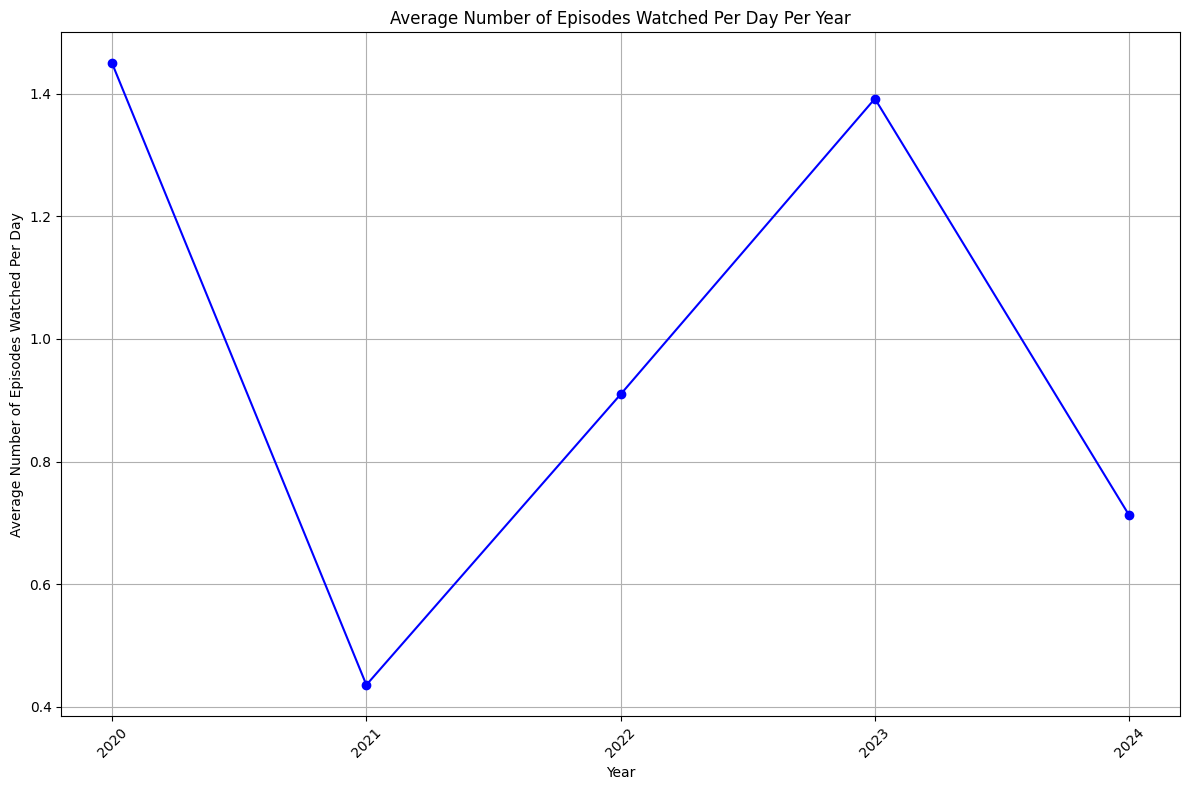

In [620]:
# Calculate the total number of episodes watched per year
total_episodes_per_year = netflix_data.groupby('Year').size()

# Calculate the number of days with any episodes watched per year
days_with_episodes_per_year = netflix_data.groupby('Year')['Date'].nunique()

# Calculate the average number of episodes watched per day per year
average_episodes_per_day_per_year = total_episodes_per_year / 365

# Plotting the average number of episodes watched per day for each year as a line plot
plt.figure(figsize=(12, 8))
plt.plot(average_episodes_per_day_per_year.index, average_episodes_per_day_per_year, marker='o', linestyle='-', color='b')
plt.title('Average Number of Episodes Watched Per Day Per Year')
plt.xlabel('Year')
plt.ylabel('Average Number of Episodes Watched Per Day')
plt.grid(True)
plt.xticks(average_episodes_per_day_per_year.index, rotation=45)
plt.tight_layout()

# Show plot
plt.show()


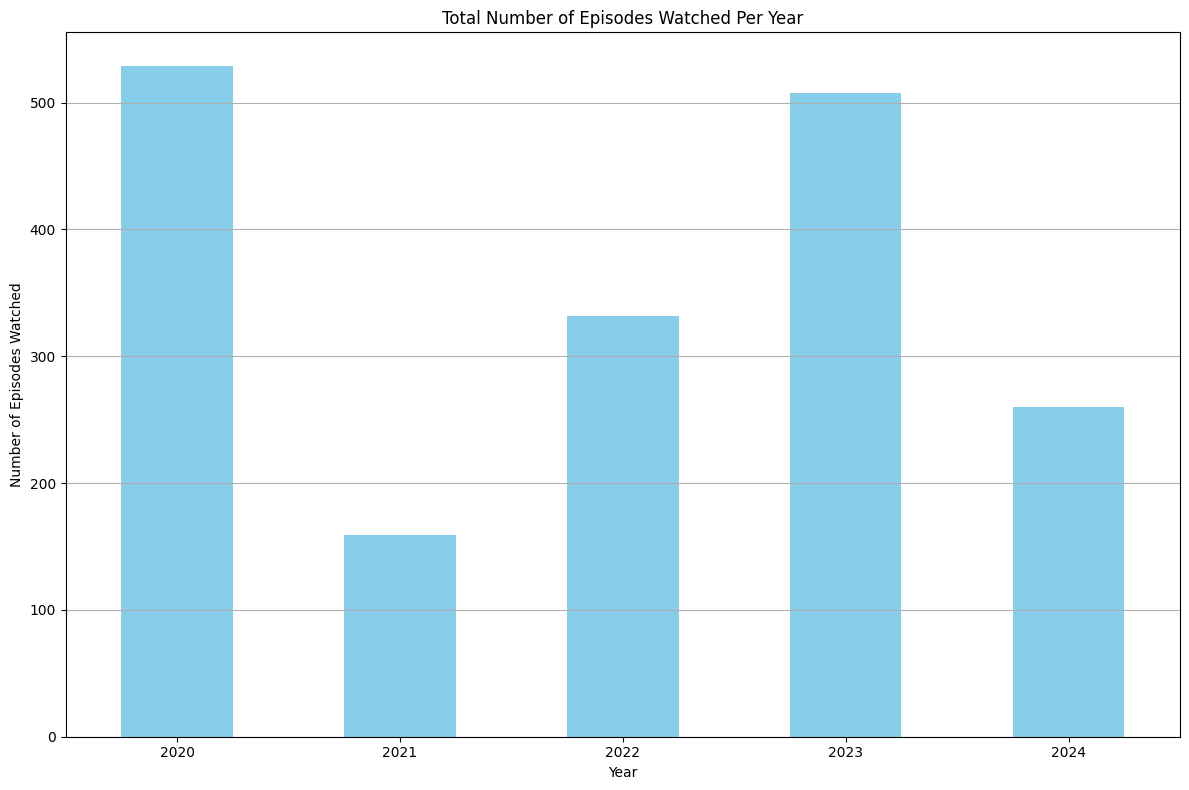

In [621]:
# Calculate the cumulative number of episodes watched per year
episodes_per_year = netflix_data.groupby('Year').size()

# Plotting the cumulative number of episodes watched per year as a bar chart
plt.figure(figsize=(12, 8))
episodes_per_year.plot(kind='bar', color='skyblue')
plt.title('Total Number of Episodes Watched Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Episodes Watched')
plt.grid(axis='y')
plt.xticks(rotation=0)
plt.tight_layout()

# Show plot
plt.show()


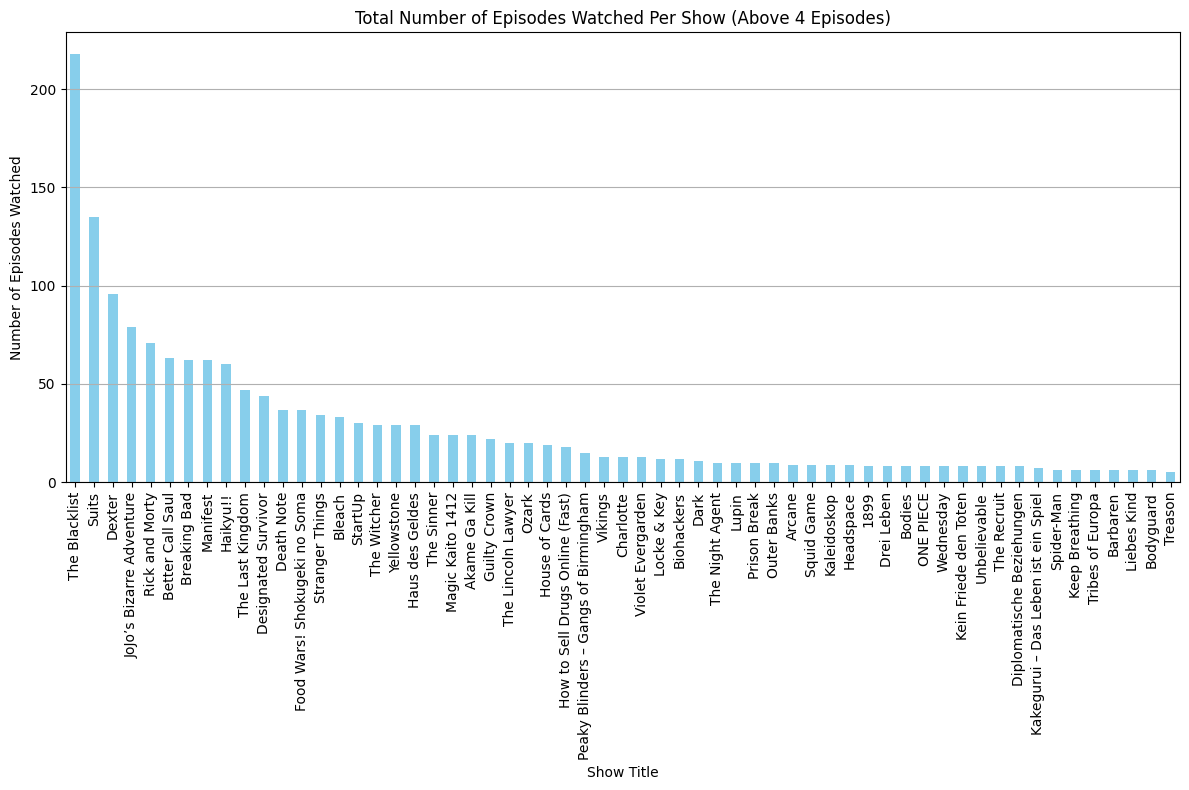

In [622]:
# Calculate the number of episodes watched per show
episodes_per_show = netflix_data['Show_Title'].value_counts()

# Filter out shows with less than 4 episodes watched
episodes_above_4 = episodes_per_show[episodes_per_show >= 4]

# Plotting the filtered number of episodes watched per show as a bar chart
plt.figure(figsize=(12, 8))
episodes_above_4.sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Total Number of Episodes Watched Per Show (Above 4 Episodes)')
plt.xlabel('Show Title')
plt.ylabel('Number of Episodes Watched')
plt.grid(axis='y')
plt.xticks(rotation=90)
plt.tight_layout()

# Show plot
plt.show()


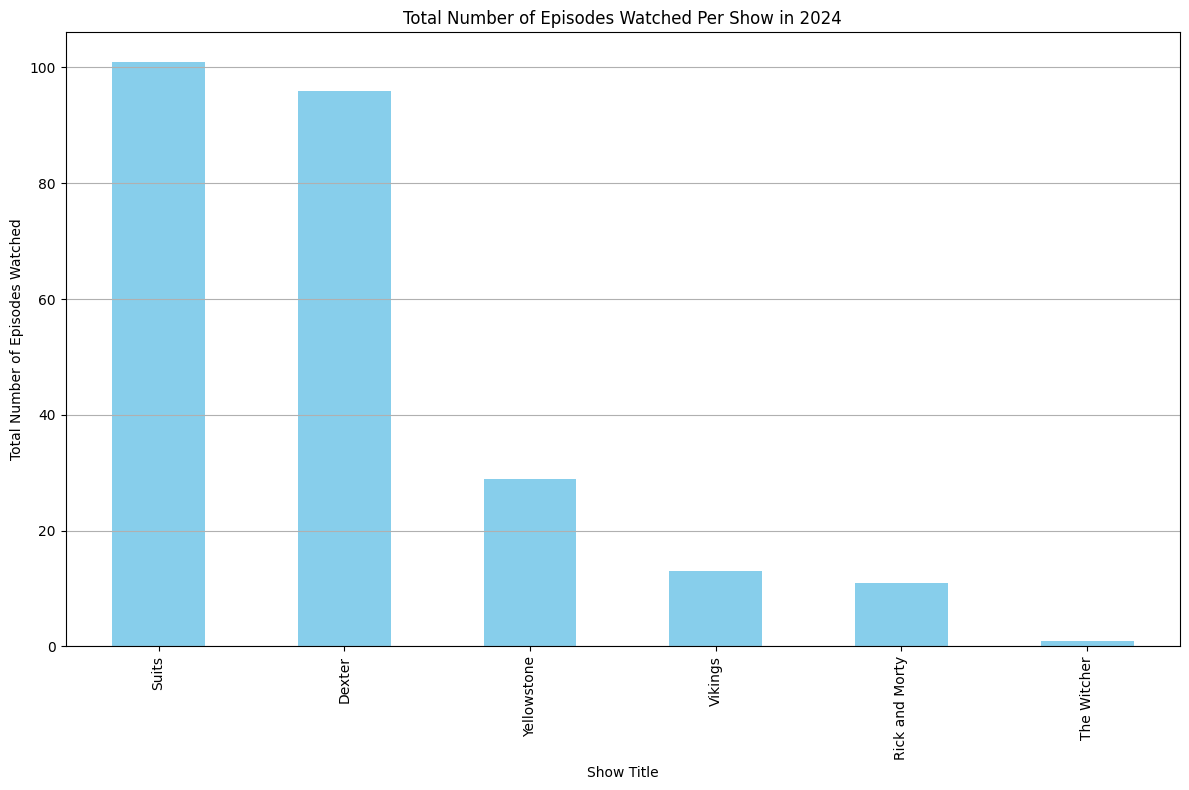

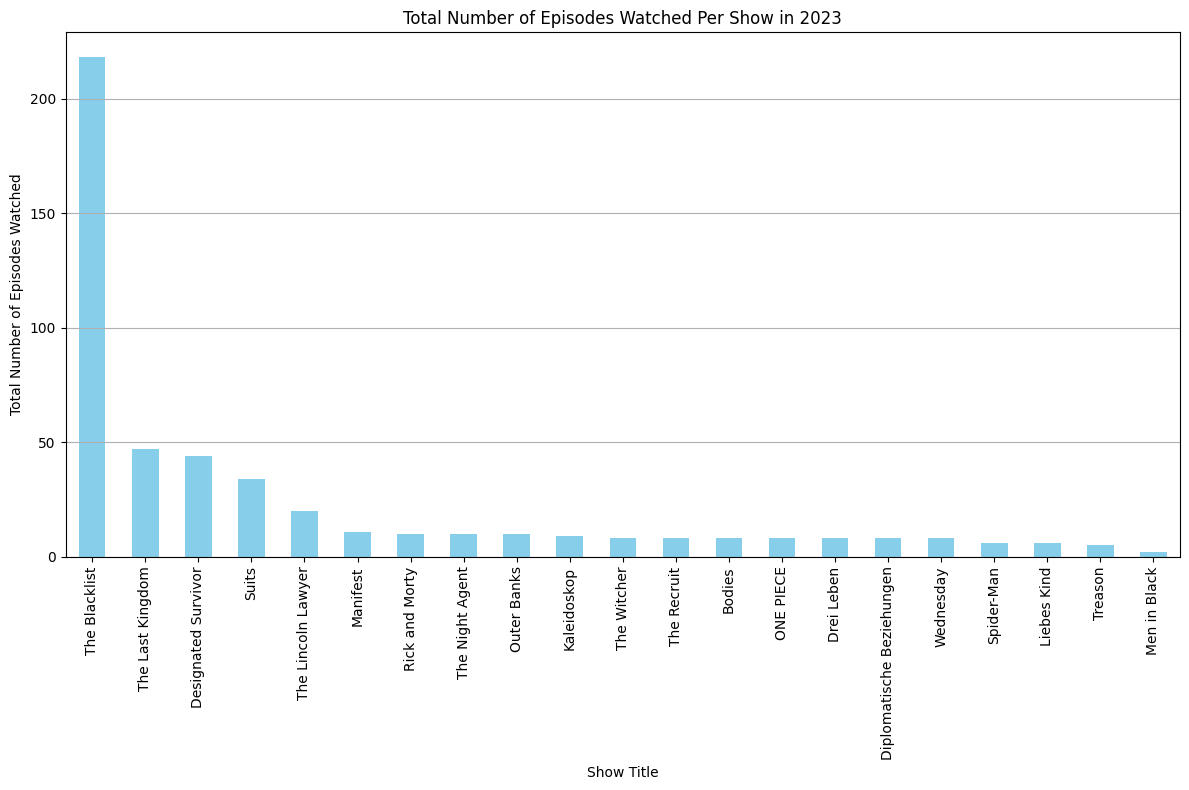

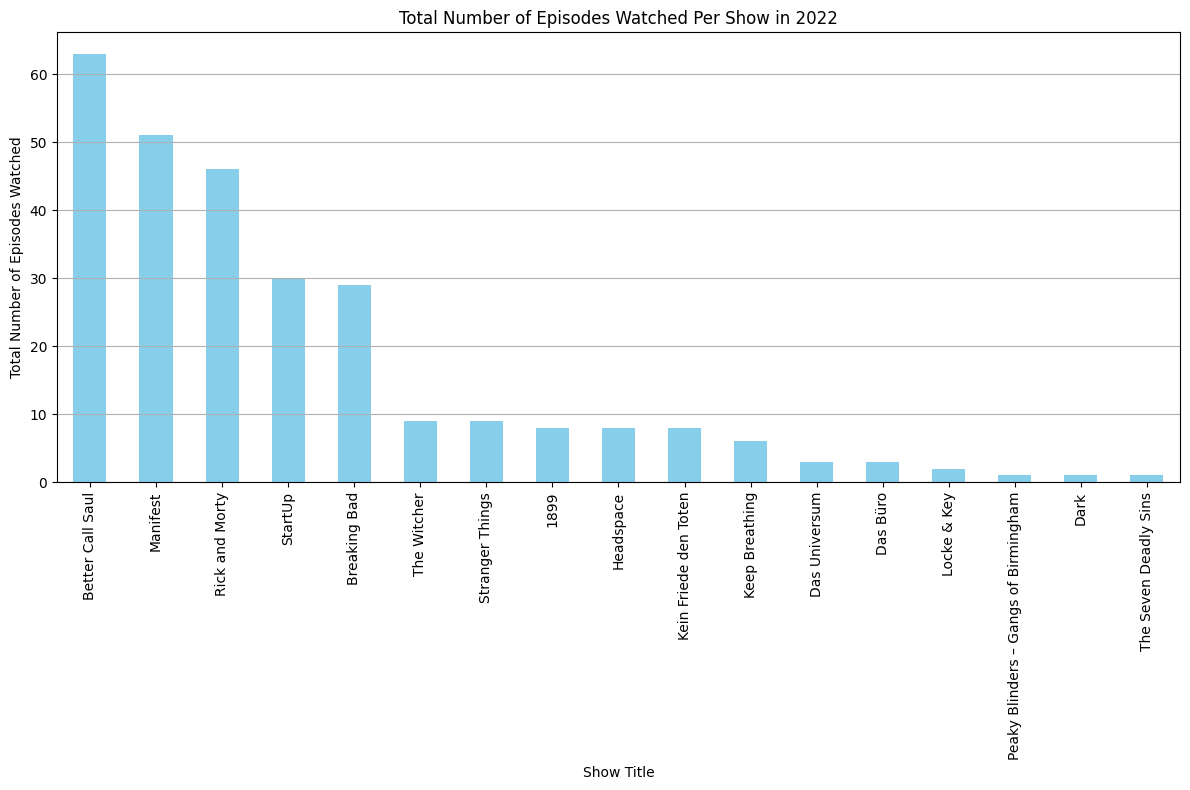

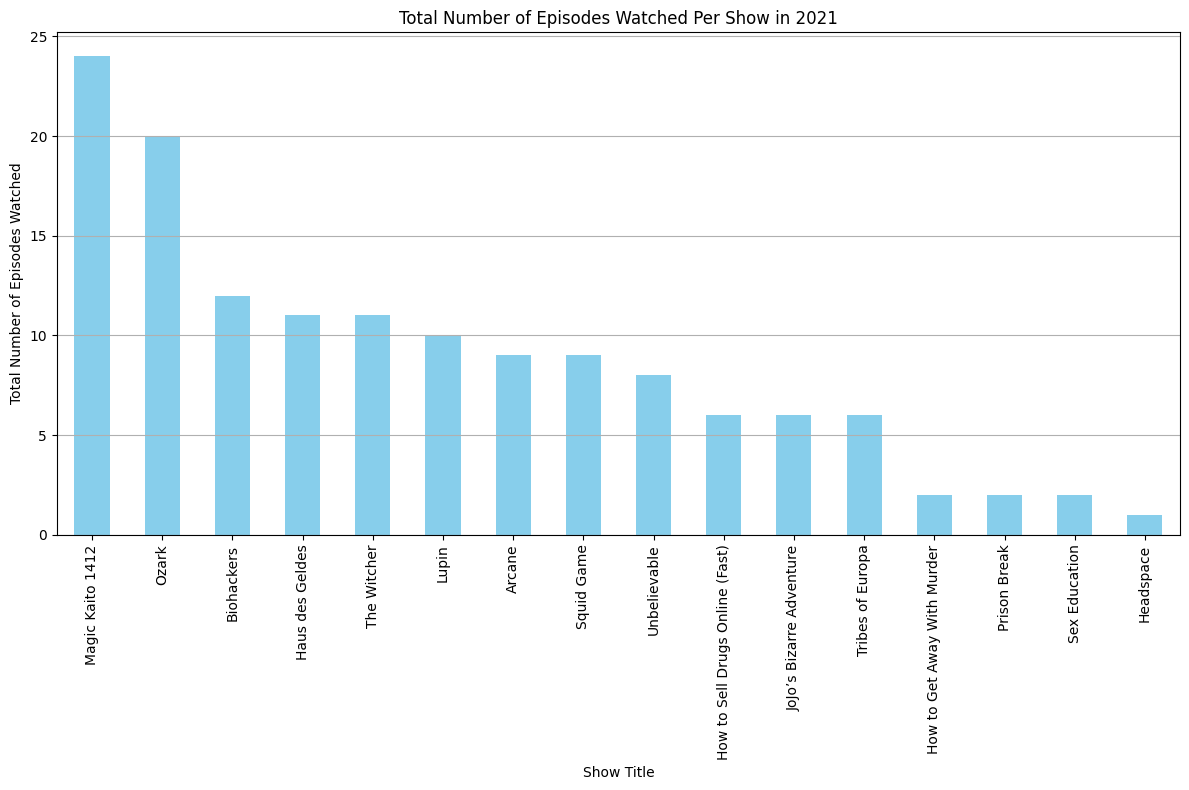

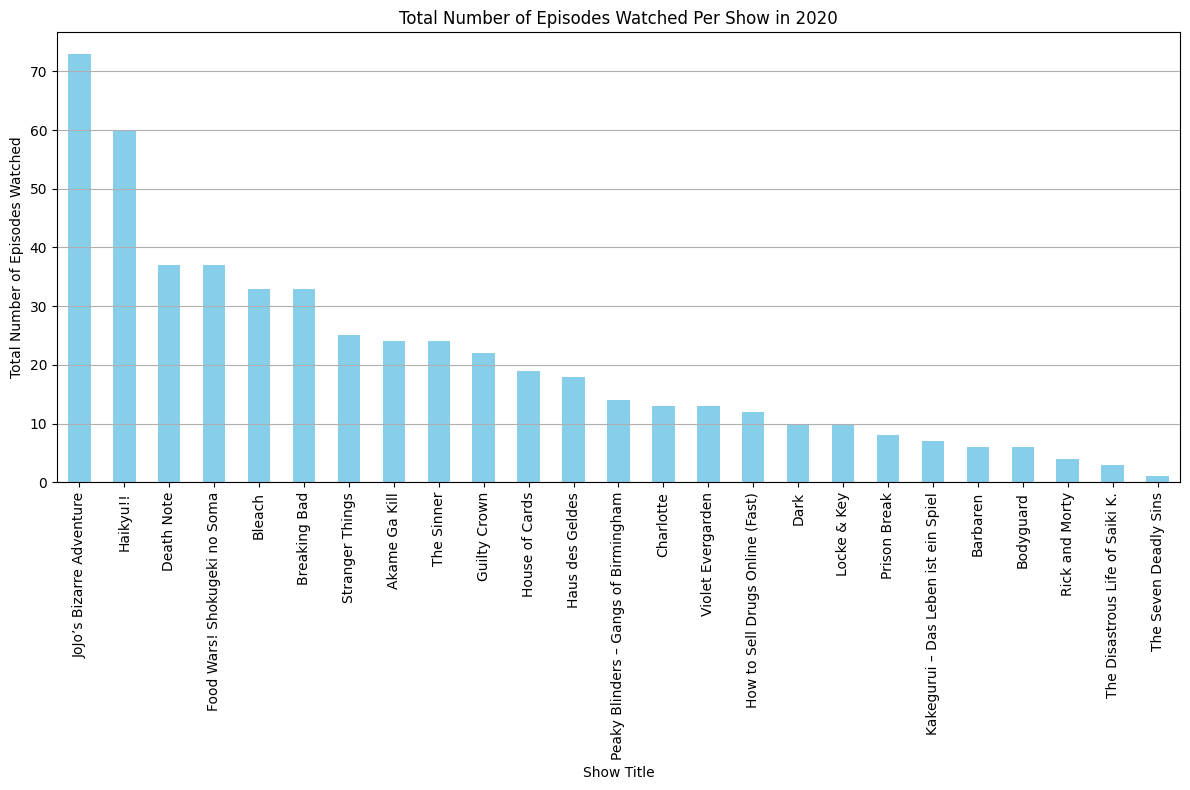

In [623]:
# Function to plot total hours watched per show for a given year
def plot_total_hours_per_show_by_year(year):
    data_year = netflix_data[netflix_data['Year'] == year]
    episodes_per_show_year = data_year.groupby('Show_Title')['Title'].count()
    episodes_per_show_year_above_1 = episodes_per_show_year[episodes_per_show > 1]
    
    plt.figure(figsize=(12, 8))
    episodes_per_show_year_above_1.sort_values(ascending=False).plot(kind='bar', color='skyblue')
    plt.title(f'Total Number of Episodes Watched Per Show in {year}')
    plt.xlabel('Show Title')
    plt.ylabel('Total Number of Episodes Watched')
    plt.grid(axis='y')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

# List of other years in the dataset
years = netflix_data['Year'].unique()

# Plotting the charts for each other year
for year in years:
    plot_total_hours_per_show_by_year(year)


In [624]:
# List the shows watched in order of date
shows_watched_by_date = netflix_data[['Date', 'Show_Title']].sort_values(by='Date')
shows_watched_by_date.head()


,Date,Show_Title
1787,2020-02-07,Haus des Geldes
1781,2020-02-07,Haus des Geldes
1782,2020-02-07,Haus des Geldes
1786,2020-02-07,Haus des Geldes
1784,2020-02-07,Haus des Geldes


In [625]:
# Aggregate multiple entries with the same show title to one row with the first date of the group
aggregated_shows_watched = shows_watched_by_date.groupby('Show_Title').first().reset_index()
aggregated_shows_watched.head()


,Show_Title,Date
0,,2020-09-18
1,1899,2022-11-17
2,8 Mile,2024-05-31
3,Akame Ga Kill,2020-03-23
4,American Psycho,2022-06-11


In [626]:
# Sort the aggregated list of shows watched by date
aggregated_shows_watched_sorted = aggregated_shows_watched.sort_values(by='Date', ascending=False).reset_index(drop=True)
aggregated_shows_watched_sorted.head()


,Show_Title,Date
0,Vikings,2024-07-19
1,The Rookie,2024-07-08
2,Top Gun,2024-06-26
3,8 Mile,2024-05-31
4,The OA,2024-05-26


In [627]:
# Add the episode count to the aggregated list of shows
episode_counts = netflix_data['Show_Title'].value_counts().reset_index()
episode_counts.columns = ['Show_Title', 'Episode_Count']

# Merge the episode count with the aggregated list
aggregated_shows_watched_with_counts = aggregated_shows_watched_sorted.merge(episode_counts, on='Show_Title', how='left')
aggregated_shows_watched_with_counts

,Show_Title,Date,Episode_Count
0,Vikings,2024-07-19,13
1,The Rookie,2024-07-08,1
2,Top Gun,2024-06-26,1
3,8 Mile,2024-05-31,1
4,The OA,2024-05-26,1
...,...,...,...
181,Stranger Things,2020-02-10,34
182,Prison Break,2020-02-09,10
183,Die Deutschen,2020-02-08,1
184,"Your Name. – Gestern, heute und für immer",2020-02-07,1


### Attention only correct for Jan Lieders Data

In [628]:
# Define the average episode lengths for the top 25 shows
average_episode_lengths_25 = {
    "The Blacklist": 43,
    "Suits": 42,
    "Dexter": 55,
    "JoJo’s Bizarre Adventure": 24,
    "Rick and Morty": 22,
    "Better Call Saul": 47,
    "Breaking Bad": 47,
    "Manifest": 42,
    "Haikyu!!": 24,
    "The Last Kingdom": 58,
    "Designated Survivor": 42,
    "Death Note": 23,
    "Food Wars! Shokugeki no Soma": 24,
    "Stranger Things": 50,
    "Bleach": 24,
    "StartUp": 45,
    "The Witcher": 60,
    "Yellowstone": 42,
    "Haus des Geldes": 50,
    "The Sinner": 45,
    "Magic Kaito 1412": 24,
    "Akame Ga Kill": 23,
    "Guilty Crown": 24,
    "The Lincoln Lawyer": 50,
    "Ozark": 60
}

# Create a DataFrame for the top 25 shows with their average episode lengths
top_25_shows_df = pd.DataFrame(list(average_episode_lengths_25.items()), columns=['Show_Title', 'Average_Episode_Length_Minutes'])

# Merge this information back into the main dataset
netflix_data = netflix_data.merge(top_25_shows_df, on='Show_Title', how='left')

# For shows not in the top 25, fill in with the general average of 40 minutes
netflix_data['Average_Episode_Length_Minutes'] = netflix_data['Average_Episode_Length_Minutes'].fillna(40)

In [629]:
# Identify the top 25 shows by episode count
top_25_shows_by_episodes = netflix_data['Show_Title'].value_counts().head(25)

# Display the top 25 shows
top_25_shows_by_episodes

Show_Title
The Blacklist                   218
Suits                           135
Dexter                           96
JoJo’s Bizarre Adventure         79
Rick and Morty                   71
Better Call Saul                 63
Breaking Bad                     62
Manifest                         62
Haikyu!!                         60
The Last Kingdom                 47
Designated Survivor              44
Death Note                       37
Food Wars! Shokugeki no Soma     37
Stranger Things                  34
Bleach                           33
StartUp                          30
The Witcher                      29
Yellowstone                      29
Haus des Geldes                  29
The Sinner                       24
Magic Kaito 1412                 24
Akame Ga Kill                    24
Guilty Crown                     22
The Lincoln Lawyer               20
Ozark                            20
Name: count, dtype: int64

<Figure size 1200x800 with 0 Axes>

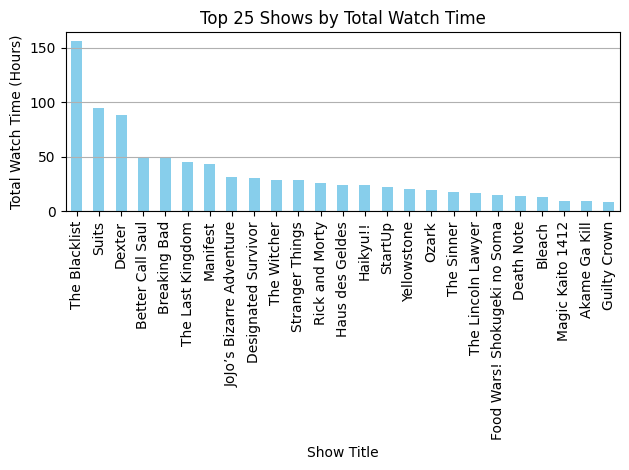

In [630]:
# Calculate the total watch time for the top 25 shows by episode count
top_25_shows_by_episodes_df = top_25_shows_by_episodes.reset_index()
top_25_shows_by_episodes_df.columns = ['Show_Title', 'Episode_Count']

# Merge the average episode lengths into the top 25 shows dataframe
top_25_shows_with_lengths = top_25_shows_by_episodes_df.merge(top_25_shows_df, on='Show_Title', how='left')

# Calculate the total watch time in minutes
top_25_shows_with_lengths['Total_Watch_Time_Minutes'] = top_25_shows_with_lengths['Episode_Count'] * top_25_shows_with_lengths['Average_Episode_Length_Minutes']

# Convert total watch time to hours
top_25_shows_with_lengths['Total_Watch_Time_Hours'] = top_25_shows_with_lengths['Total_Watch_Time_Minutes'] / 60

# Sort the top 25 shows by total watch time in descending order
top_25_shows_sorted_by_watch_time = top_25_shows_with_lengths.sort_values(by='Total_Watch_Time_Hours', ascending=False)

# Plotting the total watch time for the top 25 shows as a bar chart
plt.figure(figsize=(12, 8))
top_25_shows_sorted_by_watch_time.plot(kind='bar', x='Show_Title', y='Total_Watch_Time_Hours', color='skyblue', legend=False)
plt.title('Top 25 Shows by Total Watch Time')
plt.xlabel('Show Title')
plt.ylabel('Total Watch Time (Hours)')
plt.grid(axis='y')
plt.xticks(rotation=90)
plt.tight_layout()

# Show plot
plt.show()


In [631]:
# Group by year and calculate the total minutes watched per day for each year
total_minutes_per_day_per_year = netflix_data.groupby(['Year', 'Date'])['Average_Episode_Length_Minutes'].sum()

# Convert minutes to hours and calculate the average hours per day for each year
total_hours_per_day_per_year = total_minutes_per_day_per_year / 60
average_hours_per_day_per_year = total_hours_per_day_per_year.groupby('Year').mean()

# Convert the result to a DataFrame for better visualization
average_hours_per_day_per_year_df = average_hours_per_day_per_year.reset_index()
average_hours_per_day_per_year_df.columns = ['Year', 'Average_Hours_Per_Day']
average_hours_per_day_per_year_df


,Year,Average_Hours_Per_Day
0,2020,1.852903
1,2021,1.124150
2,2022,1.327290
3,2023,1.614119
4,2024,1.758407


### Correct for everyone again (estimation)

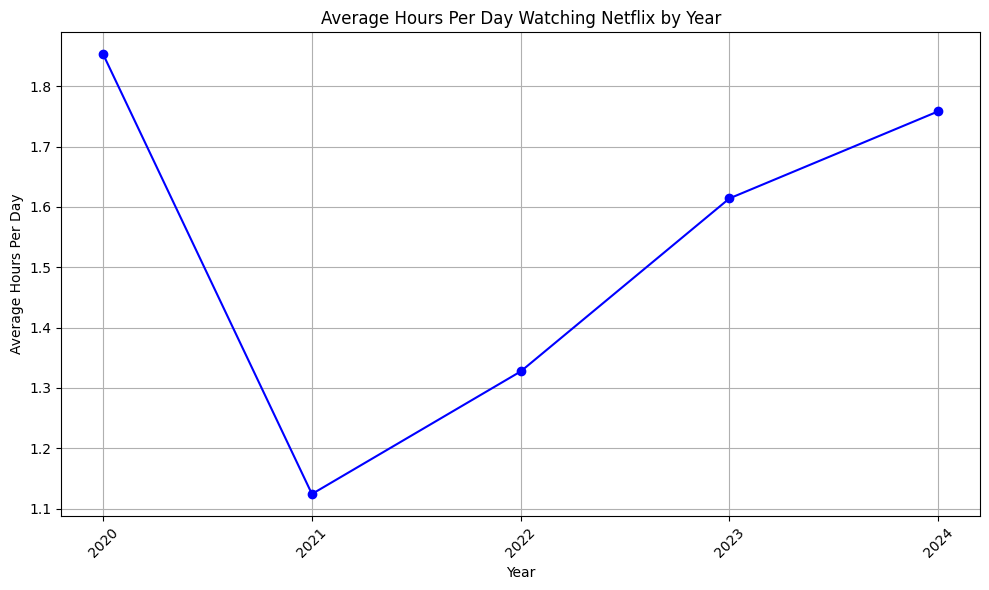

In [632]:
# Plotting the average hours per day for each year
plt.figure(figsize=(10, 6))
plt.plot(average_hours_per_day_per_year_df['Year'], average_hours_per_day_per_year_df['Average_Hours_Per_Day'], marker='o', linestyle='-', color='b')
plt.title('Average Hours Per Day Watching Netflix by Year')
plt.xlabel('Year')
plt.ylabel('Average Hours Per Day')
plt.grid(True)
plt.xticks(average_hours_per_day_per_year_df['Year'], rotation=45)
plt.tight_layout()

# Show plot
plt.show()

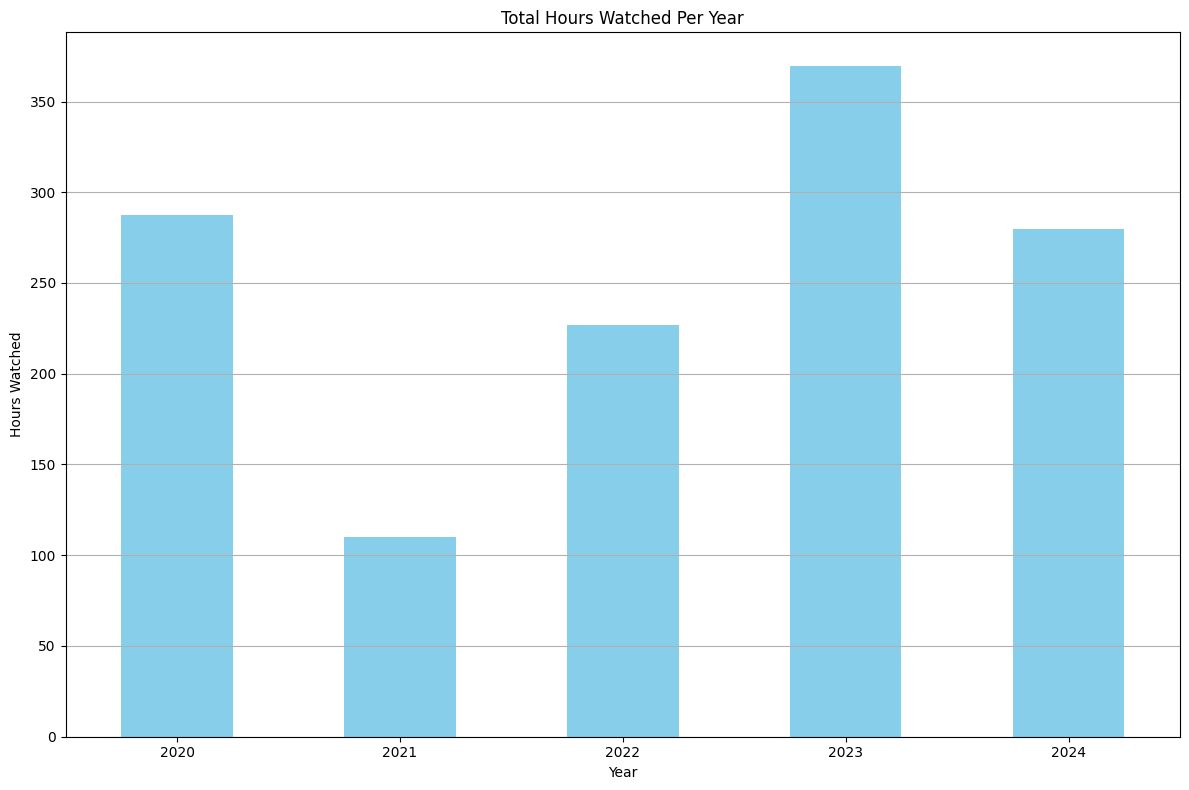

In [633]:
# Calculate the cumulative number of episodes watched per year
total_minutes_per_year = netflix_data.groupby(['Year'])['Average_Episode_Length_Minutes'].sum()
total_hours_per_year = total_minutes_per_year / 60

# TODO Remove if not Jan !!! Adds the Rookie Total Watch Time
total_hours_per_year.loc[2024] += 81

# Plotting the cumulative number of episodes watched per year as a bar chart
plt.figure(figsize=(12, 8))
total_hours_per_year.plot(kind='bar', color='skyblue')
plt.title('Total Hours Watched Per Year')
plt.xlabel('Year')
plt.ylabel('Hours Watched')
plt.grid(axis='y')
plt.xticks(rotation=0)
plt.tight_layout()

# Show plot
plt.show()
